# Tarea 08
##### Nombre: David Alejandro Díaz Pineda

In [941]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Datos los datos: 

$$x_i : 4.0,  4.2,  4.5,  4.7,  5.1,  5.5,  5.9,  6.3,  6.8,  7.1$$
$$y_i : 102.56, 130.11 ,113.18 ,142.05, 167.53, 195.14, 224.87, 256.73, 299.50, 326.72$$

### a. Construya el polinomio por mínimos cuadrados de grado 1 y calcule el error

El polinomio de grado 1 tiene la forma $mx +b$

In [942]:
# Derivadas parciales para regresión lineal
# ####################################################################
def der_parcial_1(xs: list, ys: list) -> tuple[float, float, float]:


    # coeficiente del término independiente
    c_ind = sum(ys)

    # coeficiente del parámetro 1
    c_1 = sum(xs)

    # coeficiente del parámetro 0
    c_0 = len(xs)

    return (c_1, c_0, c_ind)


def der_parcial_0(xs: list, ys: list) -> tuple[float, float, float]:
    c_1 = 0
    c_0 = 0
    c_ind = 0
    for xi, yi in zip(xs, ys):
        # coeficiente del término independiente
        c_ind += xi * yi

        # coeficiente del parámetro 1
        c_1 += xi * xi

        # coeficiente del parámetro 0
        c_0 += xi

    return (c_1, c_0, c_ind)

In [943]:
from src import ajustar_min_cuadrados

# UTILICE:
ajustar_min_cuadrados([4.0, 4.2, 4.5, 4.7, 5.1, 5.5 ,5.9, 6.3, 6.8, 7.1], [102.56, 130.11, 113.18, 142.05, 167.53, 195.14, 224.87, 256.73, 299.50, 326.72], [der_parcial_1, der_parcial_0])

[01-05 20:43:27][INFO] Se ajustarán 2 parámetros.


array([  71.61024372, -191.57241853])

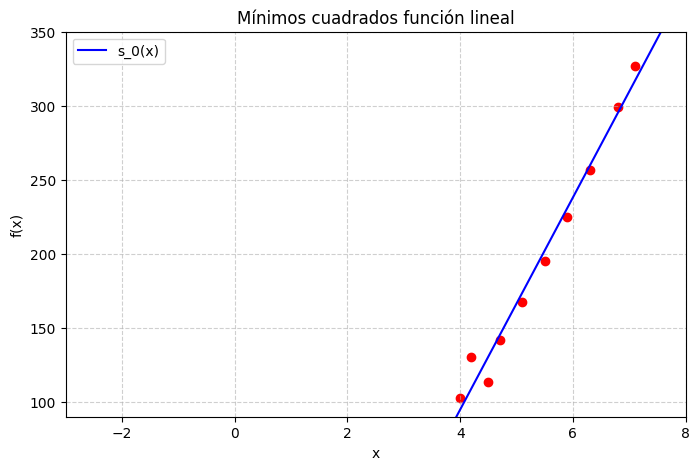

In [944]:
xs = [4.0, 4.2, 4.5, 4.7, 5.1, 5.5 ,5.9, 6.3, 6.8, 7.1]

ys = [102.56, 130.11, 113.18, 142.05, 167.53, 195.14, 224.87, 256.73, 299.50, 326.72]

m,b = 71.61024372, -191.57241853
xs0 = np.linspace(-4, 12, 200)


def s_0(x):
    return m * x + b


plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    


plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')

plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función lineal')
plt.legend()
plt.xlim(-3, 8)
plt.ylim(90, 350)
plt.show()

Para calcular el error:

In [945]:
def error_minimos_cuadrados(xs, ys, a0, a1):
    error = 0.0
    for x, y in zip(xs, ys):
        y_hat = a0 + a1 * x
        error += (y - y_hat)**2
    return error

In [946]:
E = error_minimos_cuadrados(xs, ys, b, m)
print("Error:", E)


Error: 1058.8388862638901


### b. Construya el polinomio por mínimos cuadrados de grado 2 y calcule el error.

El polinomio de grado 2 tiene la forma $ax^2 + bx + c$

In [947]:
# Derivadas parciales para regresión lineal
# ####################################################################
def der_parcial_2 (xs: list, ys: list) -> tuple[float, float, float]:
    c2 = c1 = c0 = c_ind = 0.0
    
    c_ind = sum(ys)
    c0 = len(xs)
    for xi in xs:
        c2 += xi**2
        c1 += xi


    return (c2, c1, c0, c_ind)
    

def der_parcial_1(xs: list, ys: list) -> tuple[float, float, float]:
    c2 = c1 = c0 = c_ind = 0.0
    for xi, yi in zip(xs, ys):
        c2 += xi**3
        c1 += xi**2
        c0 += xi
        c_ind += xi * yi
    return (c2, c1, c0, c_ind)


def der_parcial_0(xs: list, ys: list) -> tuple[float, float, float]:
    c2 = c1 = c0 = c_ind = 0.0
    c_1 = 0
    c_0 = 0
    c_ind = 0
    for xi, yi in zip(xs, ys):
        c2 += xi**4
        c1 += xi**3
        c0 += xi **2
        c_ind += xi **2 * yi

    return (c2, c1, c0, c_ind)

[01-05 20:43:28][INFO] Se ajustarán 3 parámetros.


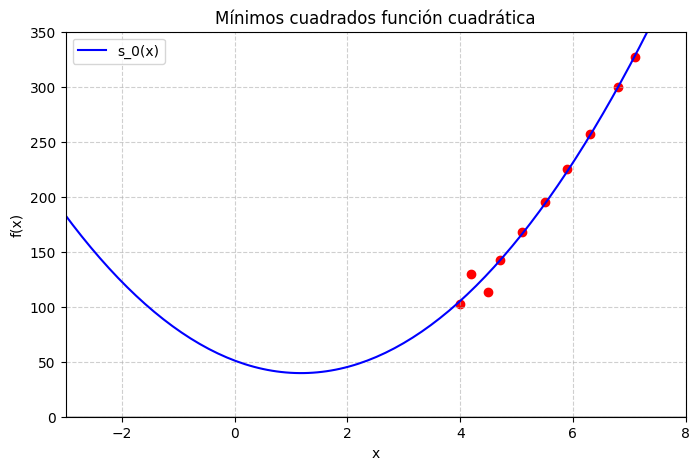

In [948]:
xs = [4.0, 4.2, 4.5, 4.7, 5.1, 5.5 ,5.9, 6.3, 6.8, 7.1]

ys = [102.56, 130.11, 113.18, 142.05, 167.53, 195.14, 224.87, 256.73, 299.50, 326.72]

a,b,c = ajustar_min_cuadrados(xs, ys, [der_parcial_2, der_parcial_1, der_parcial_0])
xs0 = np.linspace(-4, 12, 200)


def s_0(x):
    return a * x**2 + b*x +c


plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    


plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')

plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función cuadrática')
plt.legend()
plt.xlim(-3, 8)
plt.ylim(0, 350)
plt.show()

Para calcular el error:

In [949]:
def error_minimos_cuadrados(xs, ys, a, b,c):
    error = 0.0
    for x, y in zip(xs, ys):
        y_hat = a*x**2 + b*x + c
        error += (y - y_hat)**2
    return error

In [950]:
E = error_minimos_cuadrados(xs, ys, a, b, c)
print("Error:", E)


Error: 551.6562001170238


### c. Construya el polinomio por mínimos cuadrados de grado 3 y calcule el error. 

El polinomio de grado 3 tiene la forma $ax^3 + bx^2 +cx +d =0$

In [951]:
def der_parcial_0(xs: list, ys: list) -> tuple[float, float, float, float, float]:
    c3 = c2 = c1 = 0.0
    c0 = len(xs)
    c_ind = sum(ys)

    for xi in xs:
        c3 += xi**3
        c2 += xi**2
        c1 += xi

    return (c3, c2, c1, c0, c_ind)


def der_parcial_1(xs: list, ys: list) -> tuple[float, float, float, float, float]:
    c3 = c2 = c1 = c0 = c_ind = 0.0

    for xi, yi in zip(xs, ys):
        c3 += xi**4
        c2 += xi**3
        c1 += xi**2
        c0 += xi
        c_ind += xi * yi

    return (c3, c2, c1, c0, c_ind)

def der_parcial_2(xs: list, ys: list) -> tuple[float, float, float, float, float]:
    c3 = c2 = c1 = c0 = c_ind = 0.0

    for xi, yi in zip(xs, ys):
        c3 += xi**5
        c2 += xi**4
        c1 += xi**3
        c0 += xi**2
        c_ind += (xi**2) * yi

    return (c3, c2, c1, c0, c_ind)

def der_parcial_3(xs: list, ys: list) -> tuple[float, float, float, float, float]:
    c3 = c2 = c1 = c0 = c_ind = 0.0

    for xi, yi in zip(xs, ys):
        c3 += xi**6
        c2 += xi**5
        c1 += xi**4
        c0 += xi**3
        c_ind += (xi**3) * yi

    return (c3, c2, c1, c0, c_ind)

[01-05 20:43:28][INFO] Se ajustarán 4 parámetros.


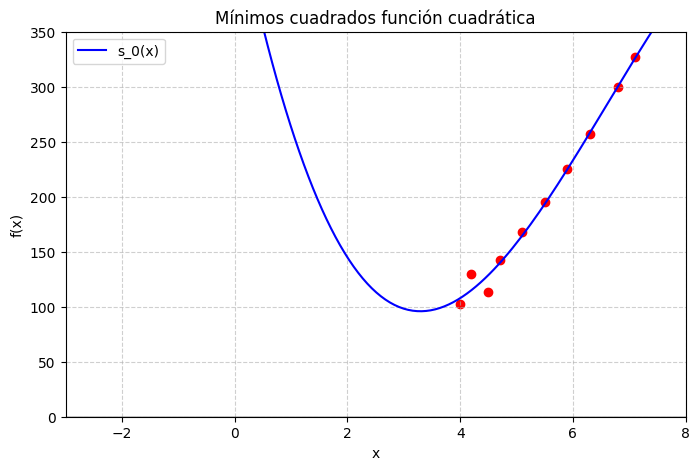

In [952]:
xs = [4.0, 4.2, 4.5, 4.7, 5.1, 5.5 ,5.9, 6.3, 6.8, 7.1]

ys = [102.56, 130.11, 113.18, 142.05, 167.53, 195.14, 224.87, 256.73, 299.50, 326.72]

a,b,c,d = ajustar_min_cuadrados(xs, ys, [der_parcial_3, der_parcial_2, der_parcial_1, der_parcial_0])
xs0 = np.linspace(-4, 12, 200)


def s_0(x):
    return a * x**3 + b*x**2 +c*x + d


plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    


plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')

plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función cuadrática')
plt.legend()
plt.xlim(-3, 8)
plt.ylim(0, 350)
plt.show()

Para calcular el error

In [953]:
def error_minimos_cuadrados(xs, ys, a, b,c,d):
    error = 0.0
    for x, y in zip(xs, ys):
        y_hat = a*x**3 + b*x**2 + c*x + d
        error += (y - y_hat)**2
    return error

In [954]:
E = error_minimos_cuadrados(xs, ys, a, b, c, d)
print("Error:", E)


Error: 518.3830647403066


### d. Construya el polinomio por mínimos cuadrados de la forma $be^{ax}$ y calcule el error. 



El modelo no es lineal, pero se puede linealizar usando logaritmos, teniendo $$y= be^{ax}$$, aplicamos $$ln(y) = ln(b) + ax$$ y definimos el cambio de variable <br> $Y=ln(y)$<br> $B=ln(b)$<br> $A=a$, así quedándonos $$Y=Ax + B$$

In [955]:
import numpy as np

xs = np.array(xs)
ys = np.array(ys)

Y = np.log(ys)   



In [956]:
def der_parcial_A(xs, Y):
    return (
        np.sum(xs**2),    
        np.sum(xs),       
        np.sum(xs * Y)     
    )


def der_parcial_B(xs, Y):
    return (
        np.sum(xs),        
        len(xs),           
        np.sum(Y)          
    )


In [957]:
A, B = ajustar_min_cuadrados(xs, Y, [der_parcial_A, der_parcial_B])


[01-05 20:43:28][INFO] Se ajustarán 2 parámetros.


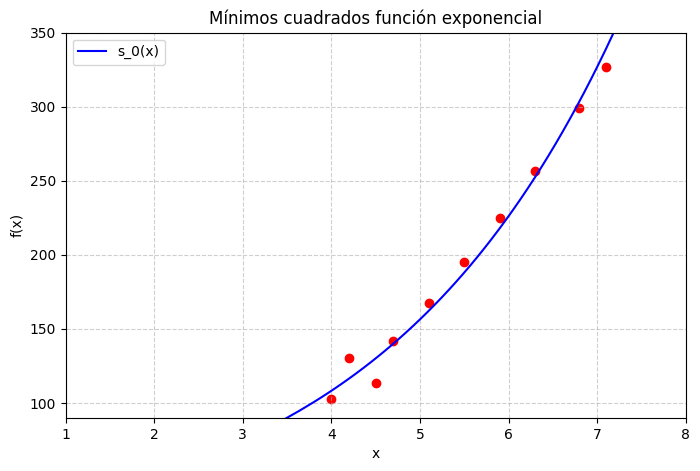

In [958]:
xs = [4.0, 4.2, 4.5, 4.7, 5.1, 5.5 ,5.9, 6.3, 6.8, 7.1]

ys = [102.56, 130.11, 113.18, 142.05, 167.53, 195.14, 224.87, 256.73, 299.50, 326.72]

a = A
b = np.exp(B)
xs0 = np.linspace(-4, 12, 200)


def s_0(x):
    return b*np.exp(a*x)


plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    


plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')

plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función exponencial')
plt.legend()
plt.xlim(1, 8)
plt.ylim(90, 350)
plt.show()

Para calcular el error 

In [959]:
def error_minimos_cuadrados(xs, ys, a, b):
    error = 0.0
    for x, y in zip(xs, ys):
        y_hat = b*np.exp(a*x)
        error += (y - y_hat)**2
    return error

In [960]:
E = error_minimos_cuadrados(xs, ys, a,b)
print("Error:", E)

Error: 821.0051092577766


### e. Construya el polinomio por mínimos cuadrados de la forma $bx^a$ y calcule el error.

Teniendo $$y = bx^a$$, aplicamos logaritmo, quedándonos $$ln(y) = ln(b) + ln(x^a)$$ realizando el cambio de variable queda

$Y = ln(y)$ <br> $X = ln(x)$ <br> $B = ln(b)$

$$Y = aX + B$$

In [961]:
X = np.log(xs)
Y = np.log(ys)

def der_parcial_a(X, Y):
    return (
        np.sum(X**2),
        np.sum(X),
        np.sum(X * Y)
    )

def der_parcial_B(X, Y):
    return (
        np.sum(X),
        len(X),
        np.sum(Y)
    )

a, B = ajustar_min_cuadrados(X, Y, [der_parcial_a, der_parcial_B])

b = np.exp(B)


[01-05 20:43:29][INFO] Se ajustarán 2 parámetros.


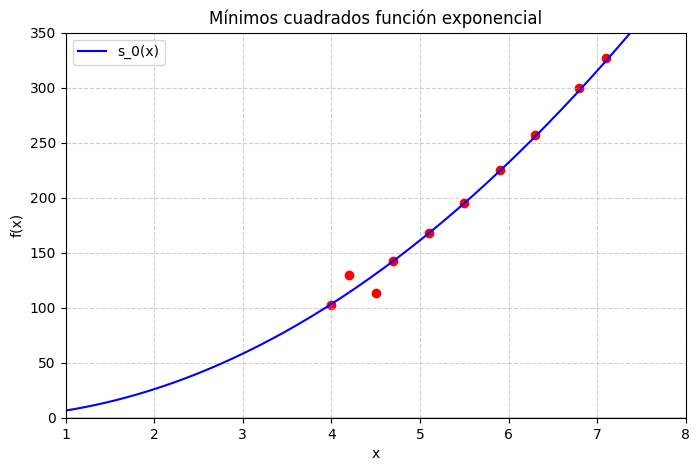

In [962]:
xs = [4.0, 4.2, 4.5, 4.7, 5.1, 5.5 ,5.9, 6.3, 6.8, 7.1]

ys = [102.56, 130.11, 113.18, 142.05, 167.53, 195.14, 224.87, 256.73, 299.50, 326.72]


xs0 = np.linspace(1, 12, 200)


def s_0(x):
    return b*(x**a)
 

plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    


plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')

plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función exponencial')
plt.legend()
plt.xlim(1, 8)
plt.ylim(0, 350)
plt.show()

Para calcular el error

In [963]:
def error_minimos_cuadrados(xs, ys, a, b):
    error = 0.0
    for x, y in zip(xs, ys):
        y_hat = b*x**a
        error += (y - y_hat)**2
    return error

In [964]:
E = error_minimos_cuadrados(xs, ys, a,b)
print("Error:", E)

Error: 581.5572726013454


# 2) Repita el ejercicio 5 para los siguientes datos

$$xi: 0.2, 0.3, 0.6, 0.9, 1.1, 1.3, 1.4, 1.6$$
$$yi: 0.050446, 0.098426, 0.33277, 0.72660, 1.0972, 1.5697, 1.8487, 2.5015$$

### a) 

In [965]:
# Derivadas parciales para regresión lineal
# ####################################################################
def der_parcial_1(xs: list, ys: list) -> tuple[float, float, float]:


    # coeficiente del término independiente
    c_ind = sum(ys)

    # coeficiente del parámetro 1
    c_1 = sum(xs)

    # coeficiente del parámetro 0
    c_0 = len(xs)

    return (c_1, c_0, c_ind)


def der_parcial_0(xs: list, ys: list) -> tuple[float, float, float]:
    c_1 = 0
    c_0 = 0
    c_ind = 0
    for xi, yi in zip(xs, ys):
        # coeficiente del término independiente
        c_ind += xi * yi

        # coeficiente del parámetro 1
        c_1 += xi * xi

        # coeficiente del parámetro 0
        c_0 += xi

    return (c_1, c_0, c_ind)

[01-05 20:43:29][INFO] Se ajustarán 2 parámetros.


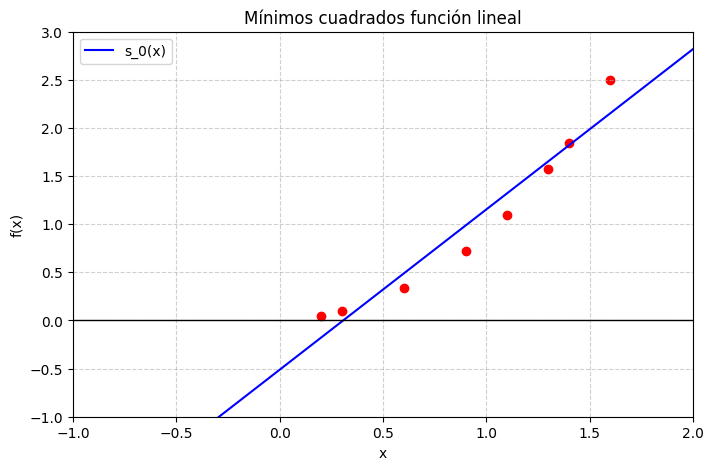

In [966]:
xs = [0.2, 0.3, 0.6, 0.9, 1.1, 1.3, 1.4, 1.6]

ys = [0.050446, 0.098426, 0.33277, 0.72660, 1.0972, 1.5697, 1.8487, 2.5015]

m,b = ajustar_min_cuadrados(xs, ys, [der_parcial_1, der_parcial_0])
xs0 = np.linspace(-1, 2, 200)


def s_0(x):
    return m * x + b


plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    


plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')

plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función lineal')
plt.legend()
plt.xlim(-1, 2)
plt.ylim(-1, 3)
plt.show()

Para calcular el error

In [967]:
def error_minimos_cuadrados(xs, ys, a0, a1):
    error = 0.0
    for x, y in zip(xs, ys):
        y_hat = a0 + a1 * x
        error += (y - y_hat)**2
    return error

In [968]:
E = error_minimos_cuadrados(xs, ys, b, m)
print("Error:", E)


Error: 0.3355898557594882


### b)

In [969]:
# Derivadas parciales para regresión lineal
# ####################################################################
def der_parcial_2 (xs: list, ys: list) -> tuple[float, float, float]:
    c2 = c1 = c0 = c_ind = 0.0
    
    c_ind = sum(ys)
    c0 = len(xs)
    for xi in xs:
        c2 += xi**2
        c1 += xi


    return (c2, c1, c0, c_ind)
    

def der_parcial_1(xs: list, ys: list) -> tuple[float, float, float]:
    c2 = c1 = c0 = c_ind = 0.0
    for xi, yi in zip(xs, ys):
        c2 += xi**3
        c1 += xi**2
        c0 += xi
        c_ind += xi * yi
    return (c2, c1, c0, c_ind)


def der_parcial_0(xs: list, ys: list) -> tuple[float, float, float]:
    c2 = c1 = c0 = c_ind = 0.0
    c_1 = 0
    c_0 = 0
    c_ind = 0
    for xi, yi in zip(xs, ys):
        c2 += xi**4
        c1 += xi**3
        c0 += xi **2
        c_ind += xi **2 * yi

    return (c2, c1, c0, c_ind)

[01-05 20:43:30][INFO] Se ajustarán 3 parámetros.


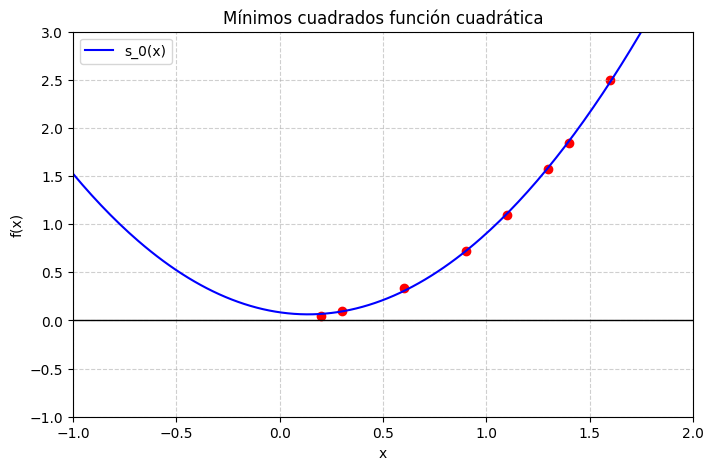

In [970]:
xs = [0.2, 0.3, 0.6, 0.9, 1.1, 1.3, 1.4, 1.6]

ys = [0.050446, 0.098426, 0.33277, 0.72660, 1.0972, 1.5697, 1.8487, 2.5015]

a,b,c = ajustar_min_cuadrados(xs, ys, [der_parcial_2,der_parcial_1, der_parcial_0])
xs0 = np.linspace(-1, 2, 200)


def s_0(x):
    return a*x**2 + b*x +c


plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    


plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')

plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función cuadrática')
plt.legend()
plt.xlim(-1, 2)
plt.ylim(-1, 3)
plt.show()

Para calcular el error

In [971]:
def error_minimos_cuadrados(xs, ys, a, b,c):
    error = 0.0
    for x, y in zip(xs, ys):
        y_hat = a*x**2 + b*x + c
        error += (y - y_hat)**2
    return error

In [972]:
E = error_minimos_cuadrados(xs, ys, a, b, c)
print("Error:", E)


Error: 0.0024199149294266927


### c)

In [973]:
def der_parcial_0(xs: list, ys: list) -> tuple[float, float, float, float, float]:
    c3 = c2 = c1 = 0.0
    c0 = len(xs)
    c_ind = sum(ys)

    for xi in xs:
        c3 += xi**3
        c2 += xi**2
        c1 += xi

    return (c3, c2, c1, c0, c_ind)


def der_parcial_1(xs: list, ys: list) -> tuple[float, float, float, float, float]:
    c3 = c2 = c1 = c0 = c_ind = 0.0

    for xi, yi in zip(xs, ys):
        c3 += xi**4
        c2 += xi**3
        c1 += xi**2
        c0 += xi
        c_ind += xi * yi

    return (c3, c2, c1, c0, c_ind)

def der_parcial_2(xs: list, ys: list) -> tuple[float, float, float, float, float]:
    c3 = c2 = c1 = c0 = c_ind = 0.0

    for xi, yi in zip(xs, ys):
        c3 += xi**5
        c2 += xi**4
        c1 += xi**3
        c0 += xi**2
        c_ind += (xi**2) * yi

    return (c3, c2, c1, c0, c_ind)

def der_parcial_3(xs: list, ys: list) -> tuple[float, float, float, float, float]:
    c3 = c2 = c1 = c0 = c_ind = 0.0

    for xi, yi in zip(xs, ys):
        c3 += xi**6
        c2 += xi**5
        c1 += xi**4
        c0 += xi**3
        c_ind += (xi**3) * yi

    return (c3, c2, c1, c0, c_ind)

[01-05 20:43:30][INFO] Se ajustarán 4 parámetros.


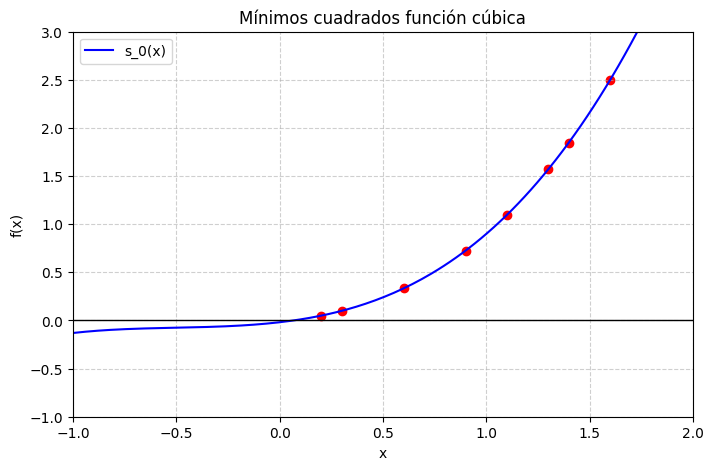

In [974]:
xs = [0.2, 0.3, 0.6, 0.9, 1.1, 1.3, 1.4, 1.6]

ys = [0.050446, 0.098426, 0.33277, 0.72660, 1.0972, 1.5697, 1.8487, 2.5015]

a,b,c, d = ajustar_min_cuadrados(xs, ys, [der_parcial_3, der_parcial_2,der_parcial_1, der_parcial_0])
xs0 = np.linspace(-1, 2, 200)


def s_0(x):
    return a*x**3 + b*x**2 +c*x + d


plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    


plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')

plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función cúbica')
plt.legend()
plt.xlim(-1, 2)
plt.ylim(-1, 3)
plt.show()

Para calcular el error

In [975]:
def error_minimos_cuadrados(xs, ys, a, b,c,d):
    error = 0.0
    for x, y in zip(xs, ys):
        y_hat = a*x**3 + b*x**2 + c*x + d
        error += (y - y_hat)**2
    return error

In [976]:
E = error_minimos_cuadrados(xs, ys, a, b, c,d)
print("Error:", E)


Error: 5.074671555627565e-06


### d)

[01-05 20:43:31][INFO] Se ajustarán 2 parámetros.


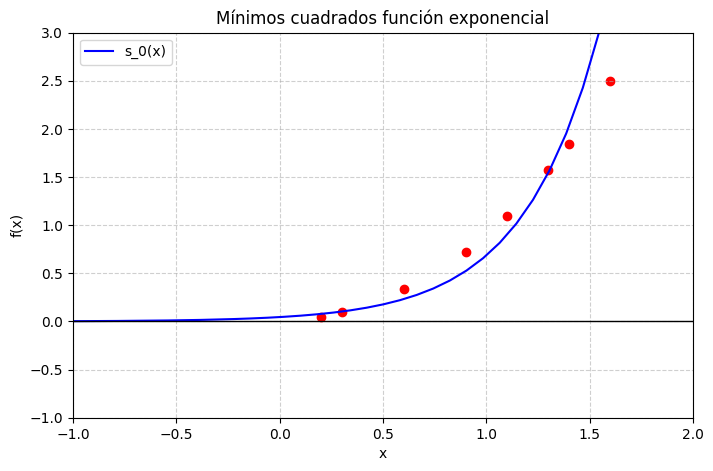

In [977]:
xs = np.array(xs)
ys = np.array(ys)

Y = np.log(ys)   

def der_parcial_A(xs, Y):
    return (
        np.sum(xs**2),    
        np.sum(xs),       
        np.sum(xs * Y)     
    )


def der_parcial_B(xs, Y):
    return (
        np.sum(xs),        
        len(xs),           
        np.sum(Y)          
    )

A, B = ajustar_min_cuadrados(xs, Y, [der_parcial_A, der_parcial_B])

xs = [0.2, 0.3, 0.6, 0.9, 1.1, 1.3, 1.4, 1.6]

ys = [0.050446, 0.098426, 0.33277, 0.72660, 1.0972, 1.5697, 1.8487, 2.5015]

a = A
b = np.exp(B)
xs0 = np.linspace(-4, 12, 200)


def s_0(x):
    return b*np.exp(a*x)


plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    


plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')

plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función exponencial')
plt.legend()
plt.xlim(-1, 2)
plt.ylim(-1, 3)
plt.show()



Para calcular el error

In [978]:
def error_minimos_cuadrados(xs, ys, a, b):
    error = 0.0
    for x, y in zip(xs, ys):
        y_hat = b*np.exp(a*x)
        error += (y - y_hat)**2
    return error

In [979]:
E = error_minimos_cuadrados(xs, ys, a, b)
print("Error:", E)


Error: 1.075048503189181


### e) 

In [980]:
X = np.log(xs)
Y = np.log(ys)

def der_parcial_a(X, Y):
    return (
        np.sum(X**2),
        np.sum(X),
        np.sum(X * Y)
    )

def der_parcial_B(X, Y):
    return (
        np.sum(X),
        len(X),
        np.sum(Y)
    )

a, B = ajustar_min_cuadrados(X, Y, [der_parcial_a, der_parcial_B])

b = np.exp(B)


[01-05 20:43:32][INFO] Se ajustarán 2 parámetros.


C:\Users\dalz2\AppData\Local\Temp\ipykernel_8676\2804352223.py:10: RuntimeWarning: invalid value encountered in power
  return b*(x**a)


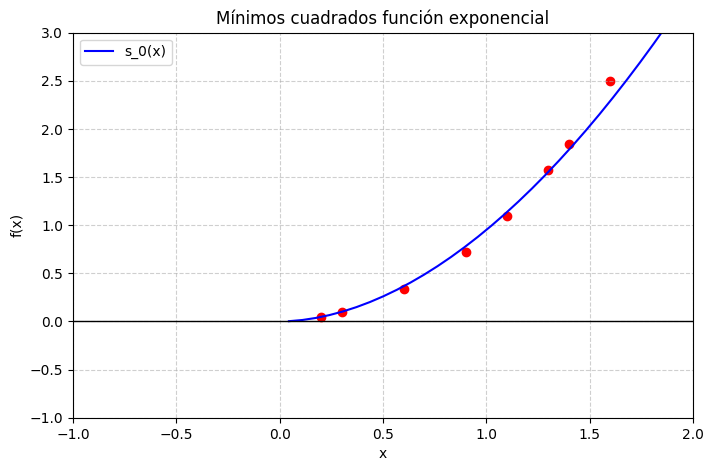

In [981]:
xs = [0.2, 0.3, 0.6, 0.9, 1.1, 1.3, 1.4, 1.6]

ys = [0.050446, 0.098426, 0.33277, 0.72660, 1.0972, 1.5697, 1.8487, 2.5015]


xs0 = np.linspace(-1, 12, 200)


def s_0(x):
    return b*(x**a)
 

plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    


plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')

plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función exponencial')
plt.legend()
plt.xlim(-1, 2)
plt.ylim(-1, 3)
plt.show()

# 3) La siguiente tabla muestra los promedios de puntos del colegio de 20 especialistas en matemáticas y cienciascomputacionales, junto con las calificaciones que recibieron estos estudiantes en la parte de matemáticas dela prueba ACT (Programa de Pruebas de Colegios Americanos) mientras estaban en secundaria. Grafique estos datos y encuentre la ecuación de la recta por mínimos cuadrados para estos datos. 


28 3.84 29 3.75
25 3.21 28 3.65
28 3.23 27 3.87
27 3.63 29 3.75
28 3.75 21 1.66
33 3.20 28 3.12
28 3.41 28 2.96
29 3.38 26 2.92
23 3.53 30 3.10
27 2.03 24 2.81


C:\Users\dalz2\AppData\Local\Temp\ipykernel_8676\1114283742.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


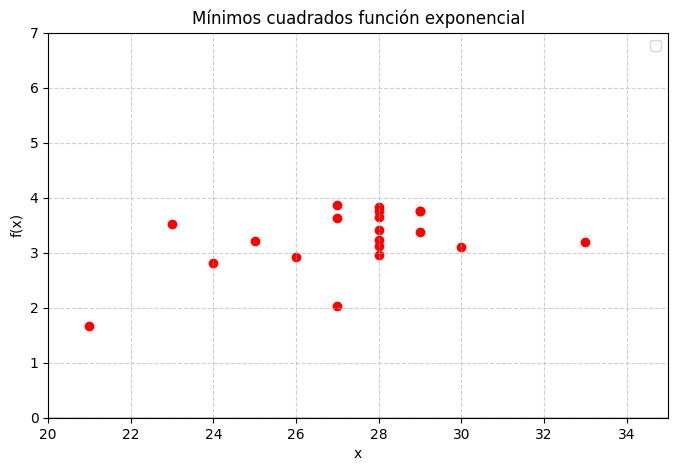

In [982]:
xs = [28, 25, 28,27,28,33,28,29,23,27,29,28,27,29,21,28,28,26,30,24]
ys = [3.84,3.21,3.23,3.63,3.75,3.2,3.41,3.38,3.53,2.03,3.75,3.65,3.87,3.75,1.66,3.12,2.96,2.92,3.10,2.81]

xs0 = np.linspace(20, 35, 200)


def s_0(x):
    return b*(x**a)
 

plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    



plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función exponencial')
plt.legend()
plt.xlim(20, 35)
plt.ylim(0, 7)
plt.show()

Como no hay cambios muy bruscos, la mejor opción es un modelo lineal

In [983]:
# Derivadas parciales para regresión lineal
# ####################################################################
def der_parcial_1(xs: list, ys: list) -> tuple[float, float, float]:


    # coeficiente del término independiente
    c_ind = sum(ys)

    # coeficiente del parámetro 1
    c_1 = sum(xs)

    # coeficiente del parámetro 0
    c_0 = len(xs)

    return (c_1, c_0, c_ind)


def der_parcial_0(xs: list, ys: list) -> tuple[float, float, float]:
    c_1 = 0
    c_0 = 0
    c_ind = 0
    for xi, yi in zip(xs, ys):
        # coeficiente del término independiente
        c_ind += xi * yi

        # coeficiente del parámetro 1
        c_1 += xi * xi

        # coeficiente del parámetro 0
        c_0 += xi

    return (c_1, c_0, c_ind)

[01-05 20:43:32][INFO] Se ajustarán 2 parámetros.


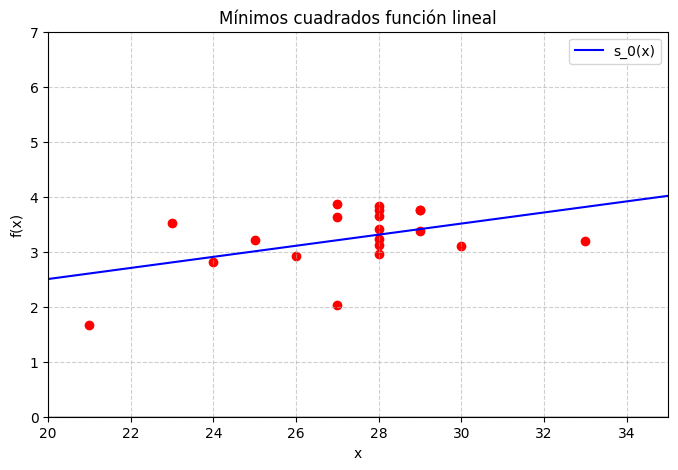

In [984]:
xs = [28, 25, 28,27,28,33,28,29,23,27,29,28,27,29,21,28,28,26,30,24]
ys = [3.84,3.21,3.23,3.63,3.75,3.2,3.41,3.38,3.53,2.03,3.75,3.65,3.87,3.75,1.66,3.12,2.96,2.92,3.10,2.81]

m,b = ajustar_min_cuadrados(xs, ys, [der_parcial_1, der_parcial_0])
xs0 = np.linspace(20, 35, 200)


def s_0(x):
    return m*x+b
 

plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    

plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')

plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función lineal')
plt.legend()
plt.xlim(20, 35)
plt.ylim(0, 7)
plt.show()

# 4. El siguiente conjunto de datos, presentado al Subcomité Antimonopolio del Senado, muestra las características comparativas de supervivencia durante un choque de automóviles de diferentes clases. Encuentre la recta por mínimos cuadrados que aproxima estos datos (la tabla muestra el porcentaje de vehículos que participaron en un accidente en los que la lesión más grave fue fatal o seria). 


In [985]:
xs = [4800, 3700, 3400, 2800, 1900]
ys = [3.1, 4.0, 5.2, 6.4, 9.6]


C:\Users\dalz2\AppData\Local\Temp\ipykernel_8676\3761805494.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


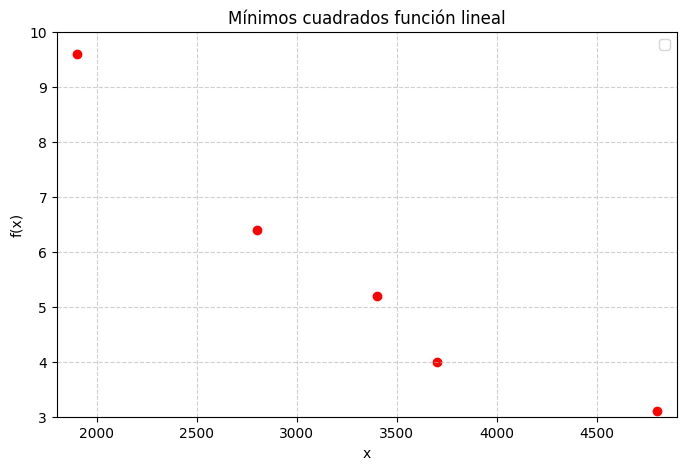

In [986]:


xs0 = np.linspace(1800, 4900, 400)

 

plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    



plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función lineal')
plt.legend()
plt.xlim(1800, 4900)
plt.ylim(3, 10)
plt.show()

In [987]:
# Derivadas parciales para regresión lineal
# ####################################################################
def der_parcial_1(xs: list, ys: list) -> tuple[float, float, float]:


    # coeficiente del término independiente
    c_ind = sum(ys)

    # coeficiente del parámetro 1
    c_1 = sum(xs)

    # coeficiente del parámetro 0
    c_0 = len(xs)

    return (c_1, c_0, c_ind)


def der_parcial_0(xs: list, ys: list) -> tuple[float, float, float]:
    c_1 = 0
    c_0 = 0
    c_ind = 0
    for xi, yi in zip(xs, ys):
        # coeficiente del término independiente
        c_ind += xi * yi

        # coeficiente del parámetro 1
        c_1 += xi * xi

        # coeficiente del parámetro 0
        c_0 += xi

    return (c_1, c_0, c_ind)

[01-05 20:43:34][INFO] Se ajustarán 2 parámetros.


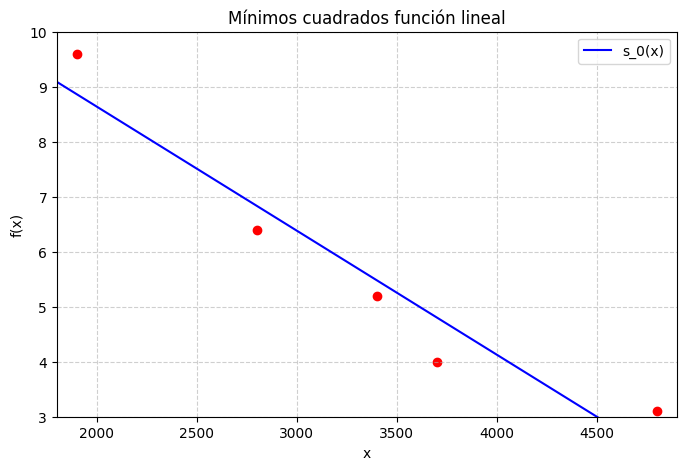

In [988]:
xs = [4800, 3700, 3400, 2800, 1900]
ys = [3.1, 4.0, 5.2, 6.4, 9.6]

m,b = ajustar_min_cuadrados(xs, ys, [der_parcial_1, der_parcial_0])
xs0 = np.linspace(1800, 4900, 400)

 
def s_0(x):
    return m*x + b


plt.figure(figsize=(8, 5))
for xi, yi in zip(xs, ys):
    plt.scatter([xi], [yi], color='red')
    
plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Mínimos cuadrados función lineal')
plt.legend()
plt.xlim(1800, 4900)
plt.ylim(3, 10)
plt.show()